# **1. Import Library**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# **2. Membaca Data & Menampilkan 5 Data Teratas**

In [4]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# **3. Data Cleansing**

In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


# **4. Preprocessing**

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

# **5. Visualisasi Line Chart - Trend Penjualan**

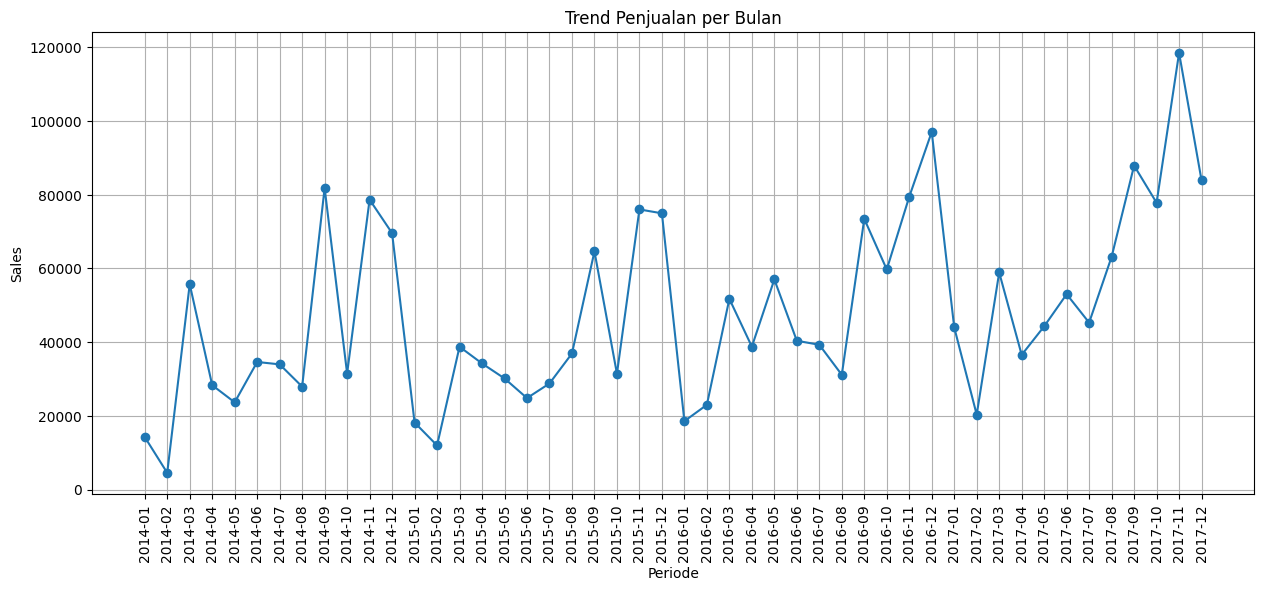

In [7]:
sales_trend = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

sales_trend.index = sales_trend.index.astype(str)

plt.figure(figsize=(15,6))
plt.plot(sales_trend.index, sales_trend.values, marker='o')
plt.title('Trend Penjualan per Bulan')
plt.xlabel('Periode')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

# **6. Visualisasi Bar Chart - Penjualan per Kategori**

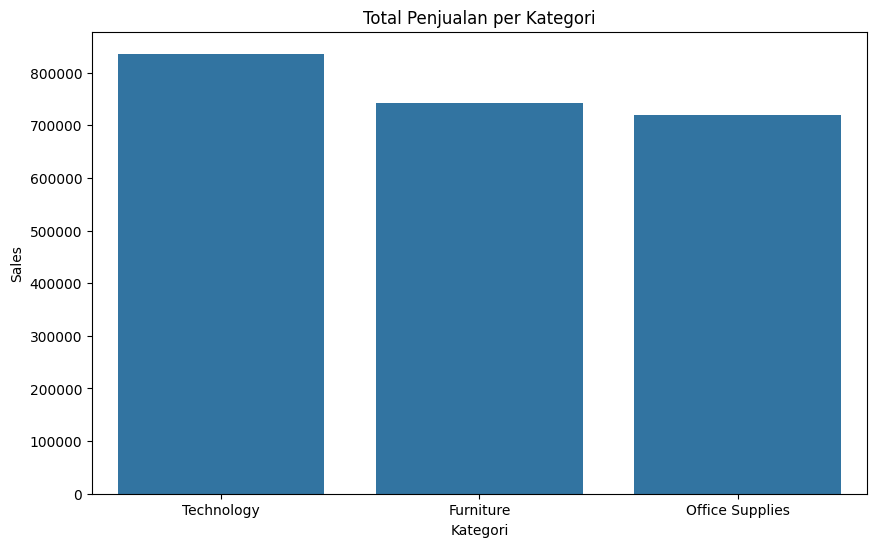

In [8]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title('Total Penjualan per Kategori')
plt.xlabel('Kategori')
plt.ylabel('Sales')
plt.show()

# **7. Persiapan Data Map -Penjualan Berdasarkan State**

In [9]:
location_sales = df.groupby('State')['Sales'].sum().reset_index()

state_abbrev = {
    'Alabama':'AL','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','Florida':'FL',
    'Georgia':'GA','Idaho':'ID','Illinois':'IL','Indiana':'IN',
    'Iowa':'IA','Kansas':'KS','Kentucky':'KY','Louisiana':'LA',
    'Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI',
    'Minnesota':'MN','Mississippi':'MS','Missouri':'MO','Montana':'MT',
    'Nebraska':'NE','Nevada':'NV','New Hampshire':'NH','New Jersey':'NJ',
    'New Mexico':'NM','New York':'NY','North Carolina':'NC',
    'North Dakota':'ND','Ohio':'OH','Oklahoma':'OK','Oregon':'OR',
    'Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC',
    'South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT',
    'Vermont':'VT','Virginia':'VA','Washington':'WA',
    'West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY'
}

location_sales['Code'] = location_sales['State'].map(state_abbrev)

location_sales = location_sales.dropna()

location_sales.head()

,State,Sales,Code
0,Alabama,19510.6400,AL
1,Arizona,35282.0010,AZ
2,Arkansas,11678.1300,AR
3,California,457687.6315,CA
4,Colorado,32108.1180,CO


# **8. Visualisasi Map - Penjualan Berdasarkan State**

In [10]:
fig = px.choropleth(
    location_sales,
    locations='Code',
    locationmode='USA-states',
    color='Sales',
    hover_name='State',
    scope='usa',
    color_continuous_scale='Blues',
    title='Distribusi Penjualan Berdasarkan State'
)

fig.update_layout(title_x=0.5)

fig.show()

# **9. Visualisasi Horizontal Bar Chart - Top 10 Sub-Category Penjualan Tertinggi**

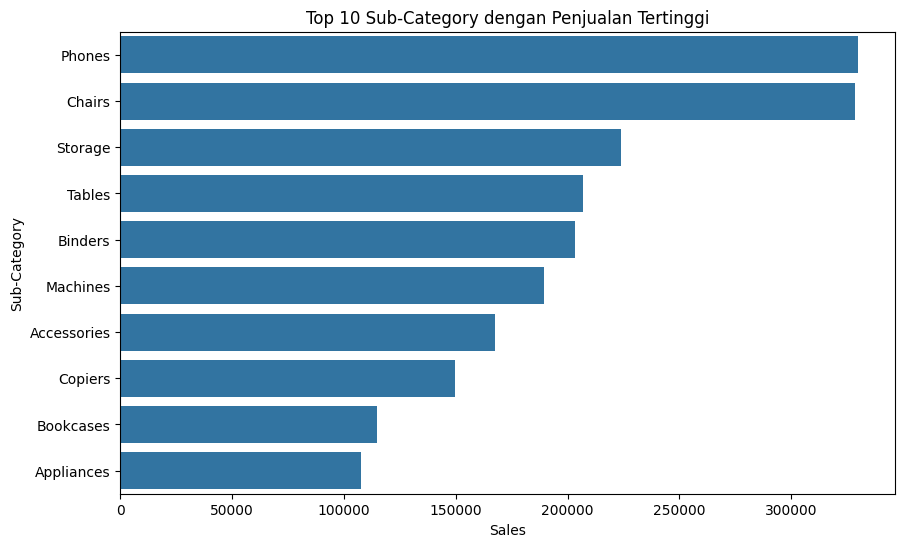

In [12]:
top_sub = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_sub.values, y=top_sub.index)

plt.title('Top 10 Sub-Category dengan Penjualan Tertinggi')
plt.xlabel('Sales')
plt.ylabel('Sub-Category')
plt.show()